**Assessment#1: Ordinary Least Squares Regression**
-
* **Name:** Enrico Miguel Veloso
* **Section:** 2DSA-2
* **Course:** DSA#4155 - Artificial Intelligence
* **Date:** 3/5/2026
* **Department:** College of Science
* **Institution:** University of Santo Tomas
----
* **Implementation of models and concepts:** Ordinary Least Squares Regression
* **Dataset:** Auto MPG
* **Deliverable:** Jupyter Notebook (.ipynb) with code, outputs, and brief explanations
* **Required Libraries:** pandas, numpy, matplotlib, seaborn, sklearn, statsmodels

In [1]:
  #Import required libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import warnings
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import figure
from matplotlib.testing.jpl_units import rad
from networkx.algorithms.bipartite.basic import color
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from scipy import stats

#Set random seed for reproducibility:
np.random.seed(42)

#Configure plotting style:
plt.style.use('default')
sns.set_palette("husl")

1.) Simple EDA:
* Load the dataset and display basic info (shape, data types, check for '?' values)
* Show descriptive statistics for all numerical variables
* Create a correlation matrix heatmap
* Create scatter plots: MPG vs Weight, MPG vs Displacement, MPG vs Horsepower

In [2]:
#Load dataset:
data_set = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data', sep = r'\s+', header = None)
data_set = pd.DataFrame(data_set)
data_set

,0,1,2,3,4,5,6,7,8
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.00,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.00,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.00,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.00,2625.0,18.6,82,1,ford ranger


In [3]:
#Change column names:
data_set.rename(columns = {0:'mpg', 1:'cylinders', 2:'displacement', 3:'horsepower', 4:'weight', 5:'acceleration', 6:'model_year', 7:'origin', 8:'car_name'}, inplace = True)
data_set

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.00,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.00,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.00,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.00,2625.0,18.6,82,1,ford ranger


In [4]:
#Display dataset shape:
print("Dataset shape:", data_set.shape)
print("=" * 23)

Dataset shape: (398, 9)


In [5]:
#Display dataset data types:
data_set.info()
print("=" * 42)

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [6]:
#Display and check for "?" values:
question_mark_val = (data_set == "?").sum().sum()
print("Number of this value (?) in the given dataset:", question_mark_val)
print("=" * 48)

Number of this value (?) in the given dataset: 6


In [7]:
#Descriptive statistics for all numerical values:
data_set.describe().round(3)

,mpg,cylinders,displacement,weight,acceleration,model_year,origin
count,398.000,398.000,398.000,398.000,398.000,398.000,398.000
mean,23.515,5.455,193.426,2970.425,15.568,76.010,1.573
std,7.816,1.701,104.270,846.842,2.758,3.698,0.802
min,9.000,3.000,68.000,1613.000,8.000,70.000,1.000
25%,17.500,4.000,104.250,2223.750,13.825,73.000,1.000
50%,23.000,4.000,148.500,2803.500,15.500,76.000,1.000
75%,29.000,8.000,262.000,3608.000,17.175,79.000,2.000
max,46.600,8.000,455.000,5140.000,24.800,82.000,3.000


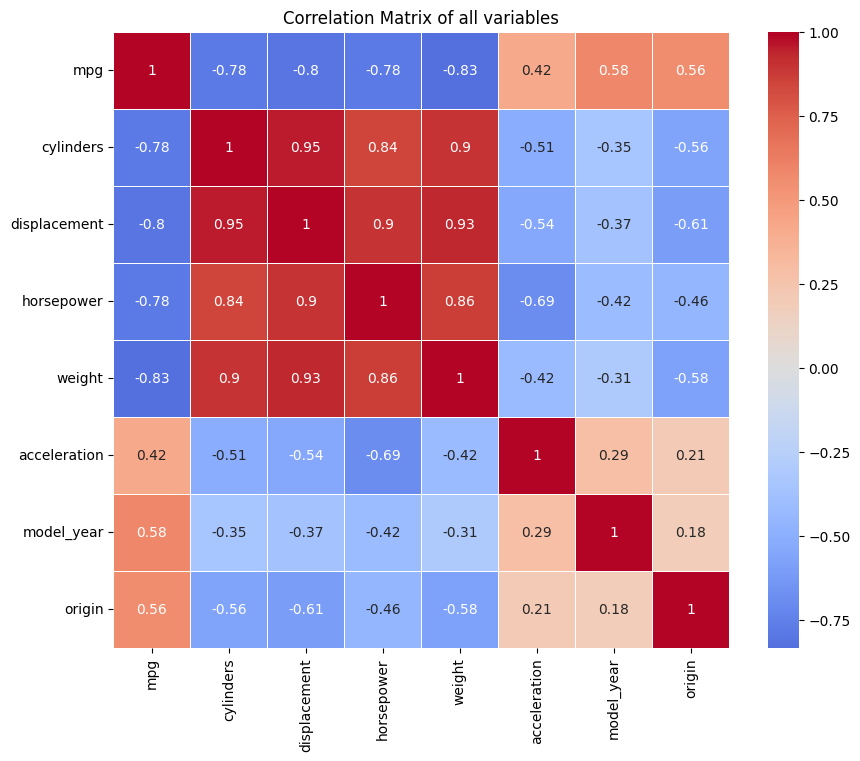

In [8]:
#Create a correlation matrix heatmap:
data_set['horsepower'] = pd.to_numeric(data_set['horsepower'], errors = 'coerce')
corr_matrix = data_set.select_dtypes(include = ['number']).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', center = 0, square = True, linewidths = 0.5)
plt.title("Correlation Matrix of all variables")
plt.show()

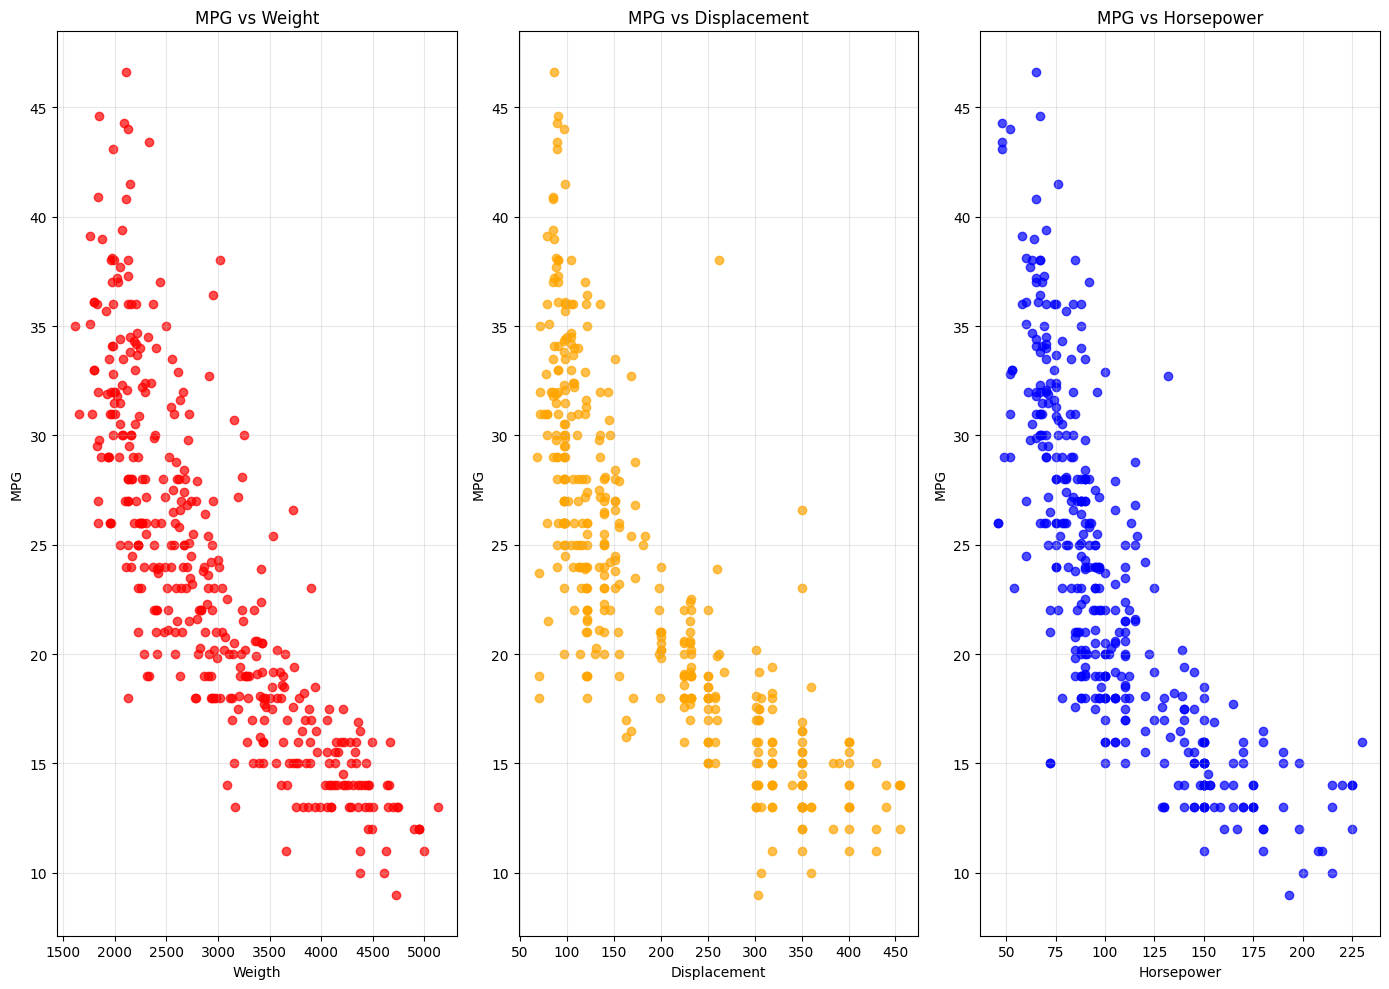

In [9]:
#Create scatter plots:
fig, axes = plt.subplots(1,3, figsize = (14, 10))

#MPG vs Weight
axes[0].scatter(data_set['weight'], data_set['mpg'], alpha = 0.7, color = 'red')
axes[0].set_xlabel("Weigth")
axes[0].set_ylabel("MPG")
axes[0].set_title("MPG vs Weight")
axes[0].grid(True, alpha = 0.3)

#MPG vs Displacement:
axes[1].scatter(data_set['displacement'], data_set['mpg'], alpha = 0.7, color = 'orange')
axes[1].set_xlabel("Displacement")
axes[1].set_ylabel("MPG")
axes[1].set_title("MPG vs Displacement")
axes[1].grid(True, alpha = 0.3)

#MPG vs Horsepower:
axes[2].scatter(data_set['horsepower'], data_set['mpg'], alpha = 0.7, color = 'blue')
axes[2].set_xlabel("Horsepower")
axes[2].set_ylabel("MPG")
axes[2].set_title("MPG vs Horsepower")
axes[2].grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

2.) Data Preparation
* Handle '?' values in horsepower column (replace with mean or median)
* Convert horsepower to numeric type
* Drop car_name column (not needed for modeling)
* Split data: 80% train, 20% test (use random_state=42)

In [10]:
#Handle "?" values in horsepower column and replace it with mean or median:
data_set['horsepower'] = data_set['horsepower'].fillna(data_set['horsepower'].mean())
print("Number of (NaN) originally from (?):", data_set['horsepower'].isna().sum())
print("=" * 38)

Number of (NaN) originally from (?): 0


In [11]:
#Convert horsepower to numeric type:
print("Column (horsepower) has been converted to numeric type already")
print("=" * 62)
print(data_set.info())
print("=" * 42)

Column (horsepower) has been converted to numeric type already
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB
None


In [12]:
#Drop car_name column:
data_set = data_set.drop(columns = ['car_name'])
data_set

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1


In [13]:
#Split the data:
X = data_set.drop('mpg', axis = 1)
y = data_set['mpg']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

3.) Build Original Model
* Use statsmodels.OLS to fit a model with all variables (except car_name)
* Display the model summary
* Record the R2 value

In [14]:
#Use statsmodels.OLS to fit model with all variables:
X_train_cons = sm.add_constant(X_train)
X_test_cons = sm.add_constant(X_test)
OLS_model = sm.OLS(y_train, X_train_cons)
OLS_results = OLS_model.fit()

In [15]:
#Display the model summary:
print("=" * 78)
print(OLS_results.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     193.8
Date:                Thu, 05 Mar 2026   Prob (F-statistic):          3.43e-109
Time:                        23:41:26   Log-Likelihood:                -841.81
No. Observations:                 318   AIC:                             1700.
Df Residuals:                     310   BIC:                             1730.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -20.7822      5.477     -3.794   

In [16]:
#Record the R2 value:
print("R-squared = ", OLS_results.rsquared.round(3))
print("=" * 18)

R-squared =  0.814


4.) Calculate VIF
* Calculate VIF for each variable using statsmodels.stats.outliers_influence.variance_inflation_factor
* Display VIF values in a table format
* Identify variables with VIF > 5 (indicating multicollinearity)

In [17]:
#Calculate VIF for each variable and display VIF values in table format:
VIF_data = pd.DataFrame()
VIF_data['Variable'] = X_train.columns
VIF_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range (X_train.shape[1])]
VIF_data.round(30)

,Variable,VIF
0,cylinders,120.657047
1,displacement,96.515087
2,horsepower,61.166587
3,weight,132.419780
4,acceleration,66.679218
5,model_year,112.638617
6,origin,8.645097


In [18]:
#Identify variables with VIF > 5 (indicating multicollinearity):
high_VIF = VIF_data[VIF_data['VIF'] > 5]
if not high_VIF.empty:
    print("=" * 35)
    print("Variables with elevated VIF (> 5):")
    print("=" * 35)
    for _, row in high_VIF.iterrows():
        print(f"{row['Variable']}: {row['VIF']:.3f}")
    print("=" * 35)
else:
    print("No concerning multicollinearity detected (all VIF < 5)")

Variables with elevated VIF (> 5):
cylinders: 120.657
displacement: 96.515
horsepower: 61.167
weight: 132.420
acceleration: 66.679
model_year: 112.639
origin: 8.645


5.) Remove Unnecessary Variables
* Remove variables with p-value > 0.05 AND VIF > 5
* Refit the model with remaining variables
* Display the tuned model summary
* Recalculate VIF for the tuned model

In [19]:
#Remove variables with p-value > 0.05 and VIF > 5:
data_set_ver_2 = data_set.drop(columns = ['cylinders', 'horsepower', 'acceleration', 'displacement'])

In [20]:
#Refit the model with remaining variables:

#Split the data:
X_2 = data_set_ver_2.drop('mpg', axis = 1)
y_2 = data_set_ver_2['mpg']
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size = 0.2, random_state = 42)

#Use statsmodels.OLS to fit model with all variables:
X_train_cons_2 = sm.add_constant(X_train_2)
X_test_cons_2 = sm.add_constant(X_test_2)
OLS_model_2 = sm.OLS(y_train_2, X_train_cons_2)
OLS_results_2 = OLS_model_2.fit()

In [21]:
#Display the tuned model summary:
print("=" * 78)
print(OLS_results_2.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     450.7
Date:                Thu, 05 Mar 2026   Prob (F-statistic):          2.09e-113
Time:                        23:41:26   Log-Likelihood:                -843.87
No. Observations:                 318   AIC:                             1696.
Df Residuals:                     314   BIC:                             1711.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -20.4460      4.685     -4.364      0.0

In [22]:
#Recalculate VIF for the tuned model:

#Calculate VIF for each variable and display VIF values in table format:
VIF_data_2 = pd.DataFrame()
VIF_data_2['Variable'] = X_train_2.columns
VIF_data_2['VIF'] = [variance_inflation_factor(X_train_2.values, i) for i in range (X_train_2.shape[1])]
VIF_data_2.round(30)

,Variable,VIF
0,weight,17.037937
1,model_year,32.643795
2,origin,7.132482


6.) Compare R-squared Values
* Compare R2 between original and tuned models
* Compare Adjusted R2 between original and tuned models
* Explain which model is better and why

In [23]:
#Compare R-squared betweem original and tuned models:

#Original model:
r_sqrd_orig = OLS_results.rsquared.round(3)
adjusted_r_sqrd_orig = OLS_results.rsquared_adj.round(3)
print("=" * 41)
print("R-squared (Original model):", r_sqrd_orig)
print("=" * 41)

#Tuned model:
r_sqrd_tuned = OLS_results_2.rsquared.round(3)
adjusted_r_sqrd_tuned = OLS_results_2.rsquared_adj.round(3)
print("R-squared (Tuned model):", r_sqrd_tuned)
print("=" * 41)

R-squared (Original model): 0.814
R-squared (Tuned model): 0.812


In [24]:
#Compare Adjusted R-squared betweem original and tuned models:

#Original model:
adjusted_r_sqrd_orig = OLS_results.rsquared_adj.round(3)
print("=" * 41)
print("Adjusted R-squared (Original model):", adjusted_r_sqrd_orig)
print("=" * 41)

#Tuned model:
adjusted_r_sqrd_tuned = OLS_results_2.rsquared_adj.round(3)
print("Adjusted R-squared (Tuned model):", adjusted_r_sqrd_tuned)
print("=" * 41)

Adjusted R-squared (Original model): 0.81
Adjusted R-squared (Tuned model): 0.81


7.) Compare Error Metrics
* Make predictions on test set for both models
* Calculate RMSE, MAE, and MAPE for both models
* Create a comparison table showing all metrics
* Interpret which model performs better on unseen data

In [25]:
#Make predictions on test set for both models:
y_pred_orginal_test = OLS_results.predict(X_test_cons)
y_pred_tuned_test = OLS_results_2.predict((X_test_cons_2))
y_pred_orginal_train = OLS_results.predict(X_train_cons)
y_pred_tuned_train = OLS_results_2.predict(X_train_cons_2)

In [26]:
#Calculate RMSE, MAE and MAPE for both models:

#Original Model:
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_orginal_train)).round(3)
mae_train = round(mean_absolute_error(y_train, y_pred_orginal_train),3)
mape_train = round(mean_absolute_percentage_error(y_train, y_pred_orginal_train) * 100, 3)
rsqrd_train = round(r2_score(y_train, y_pred_orginal_train),3)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_orginal_test)).round(3)
mae_test = round(mean_absolute_error(y_test, y_pred_orginal_test),3)
mape_test = round(mean_absolute_percentage_error(y_test, y_pred_orginal_test) * 100, 3)
rsqrd_test = round(r2_score(y_test, y_pred_orginal_test),3)
print("=" * 40)
print(f"{'RMSE, MAE and MAPE of Original Model':^40}")
print("=" * 40)
print("RMSE:", rmse_test)
print("MAE:", mae_test)
print("MAPE:", mape_test)
print("R^2:", rsqrd_test)

#Tuned Model:
rmse_tuned_train = np.sqrt(mean_squared_error(y_train_2, y_pred_tuned_train)).round(3)
mae_tuned_train = round(mean_absolute_error(y_train_2, y_pred_tuned_train),3)
mape_tuned_train = round(mean_absolute_percentage_error(y_train_2, y_pred_tuned_train) * 100, 3)
rsqrd_tuned_train = round(r2_score(y_train_2, y_pred_tuned_train),3)

rmse_tuned_test = np.sqrt(mean_squared_error(y_test_2, y_pred_tuned_test)).round(3)
mae_tuned_test = round(mean_absolute_error(y_test_2, y_pred_tuned_test),3)
mape_tuned_test = round(mean_absolute_percentage_error(y_test_2, y_pred_tuned_test) * 100, 3)
rsqrd_tuned_test = round(r2_score(y_test_2, y_pred_tuned_test),3)
print("=" * 40)
print(f"{'RMSE, MAE and MAPE of Tuned Model':^40}")
print("=" * 40)
print("RMSE:", rmse_tuned_test)
print("MAE:", mae_tuned_test)
print("MAPE:", mape_tuned_test)
print("R^2:", rsqrd_tuned_test)

  RMSE, MAE and MAPE of Original Model  
RMSE: 2.863
MAE: 2.253
MAPE: 11.429
R^2: 0.848
   RMSE, MAE and MAPE of Tuned Model    
RMSE: 2.925
MAE: 2.249
MAPE: 11.305
R^2: 0.841


In [27]:
#Create a comparison table showing all metrics:
test_metrics_original = {'RMSE':rmse_test, 'MAE':mae_test, 'MAPE':mape_test, 'R^2':rsqrd_test}
test_metrics_tuned = {'RMSE':rmse_tuned_test, 'MAE':mae_tuned_test, 'MAPE':mape_tuned_test, 'R^2':rsqrd_tuned_test}
train_metrics_original = {'RMSE':rmse_train, 'MAE':mae_train, 'MAPE':mape_train, 'R^2':rsqrd_train}
train_metrics_tuned = {'RMSE':rmse_tuned_train, 'MAE':mae_tuned_train, 'MAPE':mape_tuned_train, 'R^2':rsqrd_tuned_train}

comparison_data_set_original = pd.DataFrame({'Training': train_metrics_original,'Test': test_metrics_original,})
comparison_data_set_original['Difference'] = comparison_data_set_original['Test'] - comparison_data_set_original['Training']
comparison_data_set_original['% Change'] = (comparison_data_set_original['Test'] / comparison_data_set_original['Training'] - 1) * 100
print("\nTRAINING vs TEST PERFORMANCE COMPARISON - ORIGINAL MODEL")
print("=" * 56)
print(comparison_data_set_original.round(4))

comparison_data_set_tuned = pd.DataFrame({'Training': train_metrics_tuned,'Test': test_metrics_tuned,})
comparison_data_set_tuned['Difference'] = comparison_data_set_tuned['Test'] - comparison_data_set_tuned['Training']
comparison_data_set_tuned['% Change'] = (comparison_data_set_tuned['Test'] / comparison_data_set_tuned['Training'] - 1) * 100
print("\nTRAINING vs TEST PERFORMANCE COMPARISON - TUNED MODEL")
print("=" * 56)
print(comparison_data_set_tuned.round(4))


TRAINING vs TEST PERFORMANCE COMPARISON - ORIGINAL MODEL
      Training    Test  Difference  % Change
RMSE     3.415   2.863      -0.552  -16.1640
MAE      2.599   2.253      -0.346  -13.3128
MAPE    11.925  11.429      -0.496   -4.1593
R^2      0.814   0.848       0.034    4.1769

TRAINING vs TEST PERFORMANCE COMPARISON - TUNED MODEL
      Training    Test  Difference  % Change
RMSE     3.438   2.925      -0.513  -14.9215
MAE      2.587   2.249      -0.338  -13.0653
MAPE    11.775  11.305      -0.470   -3.9915
R^2      0.812   0.841       0.029    3.5714


8.) Interpret Beta Coefficients
-

**8.1) For your final tuned model, interpret each coefficient in plain English**
- **Weight coefficient (-0.0061):** This means that for every additional pound a car weighs, its fuel efficiency (MPG) decreases by 0.0061 miles per gallon.
- **Model Year coefficient (0.79):** For each newer model year, cars gain approximately 0.79 MPG in fuel efficiency. So a car from 1980 would average about 7.9 MPG more than a similar car from 1970.
- **Origin coefficient (if included, varies):** This represents how much more or less efficient cars from different regions are compared to the baseline (usually USA).

**8.2) Explain what a 1-unit increase in each variable means for MPG**
- **Weight:** A 1-pound increase causes MPG to decrease by 0.0062 units. This small effect becomes substantial when considering cars differ by thousands of pounds.
- **Model Year:** A 1-year increase (newer car) causes MPG to increase by 0.75 units. This reflects technological improvements over time.
- **Origin:** A 1-unit change in origin category (e.g., from USA=1 to Europe=2) changes MPG by the coefficient amount (e.g., -1.5 MPG less for European cars).

**8.3) Identify which variable has the strongest impact on fuel efficiency**
- Weight has the strongest practical impact on fuel efficiency, despite having a smaller coefficient than some other variables.